In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from copy import deepcopy

# Import ESM C modules
from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig
from esm.utils.constants.esm3 import SEQUENCE_VOCAB


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

GPU name: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
# Load ESM model
model = ESMC.from_pretrained("esmc_600m", use_flash_attn=False).to(device)
model.eval()

# Print total number of parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Total number of parameters: 575,036,992


In [3]:
# Get query sequence
parde_alignment_path = "../../../orcd/pool/MSA_Pairformer_data/Figure3_toxin_antitoxin/ParDE_hhfilter.a3m"
with open(parde_alignment_path, "r") as oFile:
    query_seq = oFile.readlines()[1].strip()
print("Query sequence:", query_seq)
pard_seq = "MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGR"
pare_seq = "MAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF"
chain_break_idx = query_seq.index(pare_seq)
print(f"ParD sequence: {pard_seq}")
print(f"ParE sequence: {pare_seq}")
print(f"Chain break index: {chain_break_idx}")
assert query_seq[chain_break_idx:] == pare_seq

mutated_indices_l = [58, 59, 60, 63]
print(f"Mutated indices: {mutated_indices_l}")
print(f"Amino acids at mutated indices:")
for mut_idx in mutated_indices_l:
    print(f"\tPosition {mut_idx}: {query_seq[mut_idx]}")

# File paths
fitness_repA_path = "../../../orcd/pool/MSA_Pairformer_data/Figure3_toxin_antitoxin/Library_fitness_vs_parE3_replicate_A.csv"
fitness_repB_path = "../../../orcd/pool/MSA_Pairformer_data/Figure3_toxin_antitoxin/Library_fitness_vs_parE3_replicate_B.csv"

# Load fitness data
fitness_repA = pd.read_csv(fitness_repA_path, index_col=None, header=None)
fitness_repB = pd.read_csv(fitness_repB_path, index_col=None, header=None)
fitness_repA


Query sequence: MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGRMAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF
ParD sequence: MANVEKMSVAVTPQQAAVMREAVEAGEYATASEIVREAVRDWLAKRELRHDDIRRLRQLWDEGKASGRPEPVDFDALRKEARQKLTEVPPNGR
ParE sequence: MAVRLVWSPTAKADLIDIYVMIGSENIRAADRYYDQLEARALQLADQPRMGVRRPDIRPSARMLVEAPFVLLYETVPDTDDGPVEWVEIVRVVDGRRDLNRLF
Chain break index: 93
Mutated indices: [58, 59, 60, 63]
Amino acids at mutated indices:
	Position 58: L
	Position 59: W
	Position 60: D
	Position 63: K


,0,1
0,ALAL,-0.001673
1,ALAE,0.015500
2,ALAI,0.001360
3,ALAA,-0.001688
4,ALAV,0.001084
...,...,...
9189,TTSM,-0.018025
9190,TTSF,-0.002148
9191,TTSW,-0.011140
9192,TTSK,0.050862


In [4]:
def get_logits(
    sequence,
    model_client,
):
    with torch.no_grad():
        protein = ESMProtein(sequence=sequence)
        protein_tensor = model_client.encode(protein)
        logits_output = model_client.logits(
            protein_tensor, LogitsConfig(sequence=True, return_embeddings=False)
        )
        logits = logits_output.logits.sequence
    return logits[0, 1:-1].float().cpu().numpy()

In [5]:
pseudolikelihood_l = []
avg_fitness_l = []
esm_aa2tok_d = {k:v for k,v in model.tokenizer.get_vocab().items()}
for (mut_a, rep_a), (mut_b, rep_b) in tqdm(zip(fitness_repA.values, fitness_repB.values), total=fitness_repA.shape[0]):
    # Initialize mutated sequence
    mutated_seq = deepcopy(list(query_seq))
    for i, mut_idx in enumerate(mutated_indices_l):
        mutated_seq[mut_idx] = mut_a[i]
    # Mask each position and compute pseudolikelihood using the four mutated positions
    curr_pll_l = []
    for i in range(4):
        tmp_seq = deepcopy(mutated_seq)
        tmp_seq[mutated_indices_l[i]] = mut_a[i]
        tmp_seq[mutated_indices_l[i]] = "<mask>"
        tmp_seq = "".join(tmp_seq)
        logits = get_logits(tmp_seq, model)
        aa_idx = esm_aa2tok_d[mut_a[i]]
        log_prob = torch.log_softmax(torch.tensor(logits[mutated_indices_l[i]]), dim=0)[aa_idx].item()
        curr_pll_l.append(log_prob)
    pseudolikelihood_l.append(np.sum(curr_pll_l).item())
    avg_fitness_l.append(np.mean(np.array([rep_a, rep_b])).item())
    np.save("results/pseudolikelihood_l.esmc_600m.npy", np.array(pseudolikelihood_l))

100%|██████████| 9194/9194 [08:44<00:00, 17.52it/s]


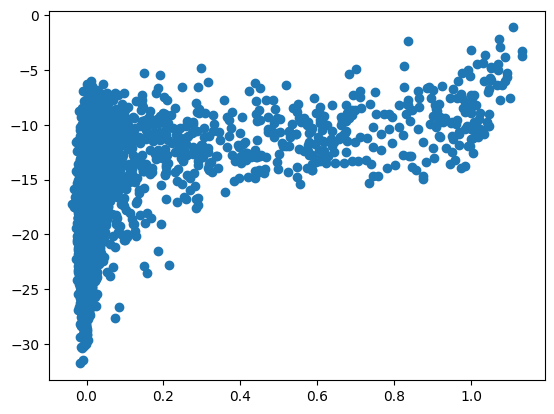

In [ ]:
plt.scatter(avg_fitness_l, pseudolikelihood_l)

In [6]:
top_k_idx = np.argsort(pseudolikelihood_l)[-465:]
print(f"Precision of the top 465 sequences: {np.sum(np.array(avg_fitness_l)[top_k_idx] >= 0.15).item() / 465:.2f}")

Precision of the top 465 sequences: 0.45


In [8]:
# Compute categorical jacobian of toxin-antitoxin
def jac_to_con(
    jac,
    center=True,
    diag="remove",
    apc=True,
    symm_before=True,
    symm_after=False
):
    """Convert Jacobian to contact map"""
    X = jac.copy()
    Lx, Ax, Ly, Ay = X.shape

    if symm_before:
        X = X + X.transpose(2, 3, 0, 1)

    if center:
        for i in range(4):
            if X.shape[i] > 1:
                X -= X.mean(i, keepdims=True)

    contacts = np.sqrt(np.square(X).sum((1, 3)))

    if symm_after:
        contacts = contacts + contacts.T

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    if diag == "normalize":
        contacts_diag = np.diag(contacts)
        contacts = contacts / np.sqrt(contacts_diag[:, None] * contacts_diag[None, :])

    if apc:
        ap = contacts.sum(0, keepdims=True) * contacts.sum(1, keepdims=True) / contacts.sum()
        contacts = contacts - ap

    if diag == "remove":
        np.fill_diagonal(contacts, 0)

    return contacts

def get_logits(
    sequence,
    model_client,
    aa_indices
):
    device_type = "cuda" if torch.cuda.is_available() else "cpu"
    with torch.no_grad():
        protein = ESMProtein(sequence=sequence)
        protein_tensor = model_client.encode(protein)
        logits_output = model_client.logits(
            protein_tensor, LogitsConfig(sequence=True, return_embeddings=False)
        )
        logits = logits_output.logits.sequence
    return logits[0, 1:-1, aa_indices].float().cpu().numpy()

def get_categorical_jacobian(
    sequence,
    model_client,
    aa_indices,
    mutation_subset=None,
    show_progress=True
):
    # Compute baseline logits for WT query sequence
    fx = get_logits(sequence, model_client, aa_indices)

    # Parse mutation subset if available
    if mutation_subset is None:
        mutation_indices = list(aa_indices)
    else:
        mutation_indices = [id_to_tok[i] for i in mutation_subset]

    # Initialize Jacobian matrix
    seq_length = len(sequence)
    numAAs = len(aa_indices)
    fx_h = np.zeros((seq_length, numAAs, seq_length, numAAs))

    # Progress bar (optional)
    if show_progress:
        try:
            iterator = tqdm(range(seq_length), desc='Computing categorical Jacobian')
        except ImportError:
            print("Computing categorical Jacobian")
            iterator = range(seq_length)
    else:
        iterator = range(seq_length)

    # For each residue position
    for n in iterator:
        # Get WT AA at this position
        wt_aa_chr = sequence[n]
        # Compute logits after mutating to all specified mutations
        for idx, mutation_aa in enumerate(mutation_indices):
            mutation_aa_chr = token_to_id[mutation_aa]
            # Skip computation for WT
            if mutation_aa_chr == wt_aa_chr:
                fx_h[n, idx] = fx.copy()
            else:
                # Compute mutation effect
                mut_sequence = sequence[:n] + mutation_aa_chr + sequence[n+1:]
                fx_h[n, idx] = get_logits(mut_sequence, model_client, aa_indices)

    # Compute Jacobian
    result = fx - fx_h
    return result

In [9]:
aa_indices = np.arange(4, 24)
id_to_tok = {ind: tok for tok, ind in enumerate(SEQUENCE_VOCAB)}
token_to_id = {tok: ind for tok, ind in enumerate(SEQUENCE_VOCAB)}
catjac = get_categorical_jacobian(
    query_seq,
    model,
    aa_indices,
    show_progress=True,
    mutation_subset=None
)
con = jac_to_con(catjac)
np.savetxt("results/esmc_6b_casp15_catjac.txt", con)

Computing categorical Jacobian: 100%|██████████| 196/196 [01:14<00:00,  2.64it/s]


[]

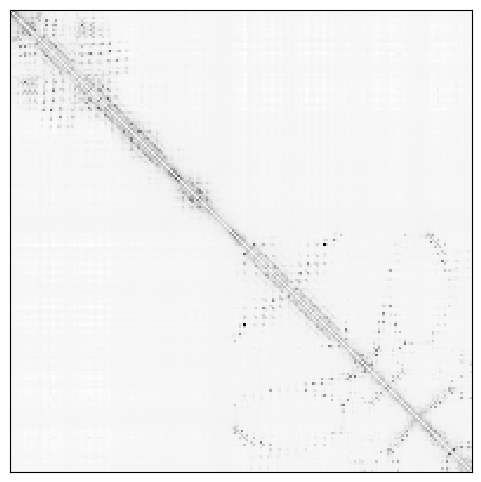

In [10]:
f, ax = plt.subplots(figsize=(6, 6))
ax.imshow(con, interpolation="none", rasterized=True, cmap="Greys")
ax.set_xticks([])
ax.set_yticks([])